# Tutorial 15 -- Cross-Kerr and Conditional Phase Accumulation

Use the three-mode storage-readout model to show how a storage superposition accumulates a conditional phase when the readout mode is occupied.

**Prerequisites.** Tutorials 08 and 14 are recommended first.


## 1. Goal

We will compare free evolution with and without a readout photon and measure the extra phase accumulated by a storage-mode superposition.


## 2. Physical Background

A cross-Kerr term shifts one bosonic mode depending on the occupation of another. For the storage superposition `(|0> + |1>) / sqrt(2)` with one readout photon present, the relative storage phase obeys `phi_cond(t) = -chi_sr t` because the unitary evolution is `exp(-i H t)`.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
total_time = 40.0 * us
dt = 0.5 * us


## 5. Model Construction


In [3]:
model = DispersiveReadoutTransmonStorageModel(
    omega_s=GHz(5.1),
    omega_r=GHz(7.3),
    omega_q=GHz(6.2),
    alpha=MHz(-220.0),
    chi_s=0.0,
    chi_r=0.0,
    chi_sr=MHz(0.030),
    kerr_s=0.0,
    kerr_r=0.0,
    n_storage=4,
    n_readout=4,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_s, omega_q_frame=model.omega_q, omega_r_frame=model.omega_r)
initial_r0 = (model.basis_state(0, 0, 0) + model.basis_state(0, 1, 0)).unit()
initial_r1 = (model.basis_state(0, 0, 1) + model.basis_state(0, 1, 1)).unit()


## 6. Pulse / Sequence Construction


In [4]:
compiled = SequenceCompiler(dt=dt).compile([], t_end=total_time)


## 7. Running the Simulation


In [5]:
result_r0 = simulate_sequence(model, compiled, initial_r0, {}, config=SimulationConfig(frame=frame, store_states=True, max_step=dt))
result_r1 = simulate_sequence(model, compiled, initial_r1, {}, config=SimulationConfig(frame=frame, store_states=True, max_step=dt))

def relative_phase(states, readout_level):
    phases = []
    ref = model.basis_state(0, 0, readout_level)
    shifted = model.basis_state(0, 1, readout_level)
    for state in states:
        amp_ref = complex(ref.overlap(state))
        amp_shift = complex(shifted.overlap(state))
        phases.append(np.angle(amp_shift / amp_ref))
    return np.unwrap(np.asarray(phases, dtype=float))

phase_r0 = relative_phase(result_r0.states, 0)
phase_r1 = relative_phase(result_r1.states, 1)
conditional_phase = phase_r1 - phase_r0
times_s = np.asarray(compiled.tlist, dtype=float)
expected_conditional_phase = cross_kerr_conditional_phase(times_s, model.chi_sr)
print(f"Maximum |simulation - theory| = {np.max(np.abs(conditional_phase - expected_conditional_phase)):.3e}")


Maximum |simulation - theory| = 1.020e-05


## 8. Visualizing the Results


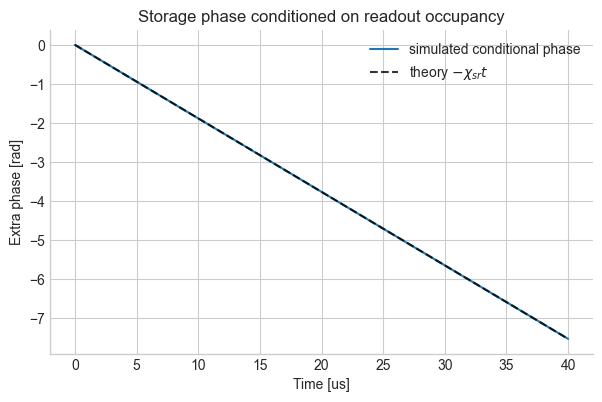

In [6]:
fig, ax = plt.subplots()
ax.plot(compiled.tlist / us, conditional_phase, label="simulated conditional phase")
ax.plot(compiled.tlist / us, expected_conditional_phase, "--", color="black", alpha=0.8, label=r"theory $-\chi_{sr} t$")
ax.set_xlabel("Time [us]")
ax.set_ylabel("Extra phase [rad]")
ax.set_title("Storage phase conditioned on readout occupancy")
ax.legend()
plt.show()


## 9. Physical Interpretation

The simulated slope follows `-chi_sr` because the conditional phase is a dynamical phase generated by `exp(-i H t)`. This is the bosonic analogue of a conditional frequency pull: one mode's phase evolution knows about the other's occupation, and the sign is fixed by the Hamiltonian convention rather than by plotting choices.


## 10. Exercises / Next Steps

- Increase `chi_sr` and confirm that the phase slope scales linearly.
- Add storage or readout self-Kerr and separate the conditional effect from the single-mode nonlinearity.
- Continue to Tutorial 17 for readout-chain modeling on top of the three-mode picture.
